Assigment Module 3

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import numpy as np
import pandas as pd

In [38]:
modfile1 = '/Users/farabiisa/Downloads/CMIP6_data/ts_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc'
modfile2 = '/Users/farabiisa/Downloads/CMIP6_data/ts_Amon_ACCESS-ESM1-5_historical_r1i1p1f1_gn_185001-201412.nc'
modfile3 = '/Users/farabiisa/Downloads/CMIP6_data/ts_Amon_MIROC6_historical_r1i1p1f1_gn_185001-201412.nc'

In [39]:
model1 = modfile1.split('/')[-1].split('_')[2]
model2 = modfile2.split('/')[-1].split('_')[2]
model3 = modfile3.split('/')[-1].split('_')[2]

print(model1, model2, model3)

IPSL-CM6A-LR ACCESS-ESM1-5 MIROC6


In [40]:
d1 = xr.open_dataset(modfile1)
d2 = xr.open_dataset(modfile2)
d3 = xr.open_dataset(modfile3)

In [41]:
d2i = d2.interp(lat=d1.lat, lon=d1.lon, method='linear')
d3i = d3.interp_like(d1, method='linear')

In [42]:
# latitude weights for model 1 grid
weights = np.cos(np.deg2rad(d1.lat))
weights.name = "weights"

# global monthly mean temperature
gm1_month = d1.ts.weighted(weights).mean(dim=('lat', 'lon'))
gm2_month = d2i.ts.weighted(weights).mean(dim=('lat', 'lon'))
gm3_month = d3i.ts.weighted(weights).mean(dim=('lat', 'lon'))

In [43]:
gm1_year = gm1_month.resample(time='YE').mean()
gm2_year = gm2_month.resample(time='YE').mean()
gm3_year = gm3_month.resample(time='YE').mean()

In [44]:
ref1 = gm1_year.sel(time=slice('1961-01-01', '1990-12-31')).mean()
ref2 = gm2_year.sel(time=slice('1961-01-01', '1990-12-31')).mean()
ref3 = gm3_year.sel(time=slice('1961-01-01', '1990-12-31')).mean()

gm1_anom = gm1_year - ref1
gm2_anom = gm2_year - ref2
gm3_anom = gm3_year - ref3

In [45]:
df_mod = pd.DataFrame({
    model1: gm1_anom.to_series(),
    model2: gm2_anom.to_series(),
    model3: gm3_anom.to_series()
})

print(df_mod.head())

            IPSL-CM6A-LR  ACCESS-ESM1-5    MIROC6
time                                             
1850-12-31     -0.752197       0.066342 -0.295693
1851-12-31     -0.565735      -0.050152 -0.333736
1852-12-31     -0.577240      -0.124327 -0.309300
1853-12-31     -0.492462      -0.091912 -0.248150
1854-12-31     -0.411804       0.013516  0.023145


In [46]:
df_mod['ens_mean'] = df_mod.mean(axis=1)
df_mod['ens_std'] = df_mod[[model1, model2, model3]].std(axis=1)

In [76]:
obs = pd.read_csv('/Users/farabiisa/Downloads/Lab_BigData_Mod2_part3/gmta_10295_stations', index_col=0, parse_dates=True)
obs.columns = ['obs_gmta']

print(obs.head())

            obs_gmta
time                
1850-12-31 -0.404145
1851-12-31 -0.039937
1852-12-31 -0.238988
1853-12-31 -0.269595
1854-12-31 -0.025059


In [82]:
common_start = max(df_mod.index.min(), obs.index.min())
common_end = min(df_mod.index.max(), obs.index.max())

df_mod = df_mod.loc[common_start:common_end]
obs = obs.loc[common_start:common_end]

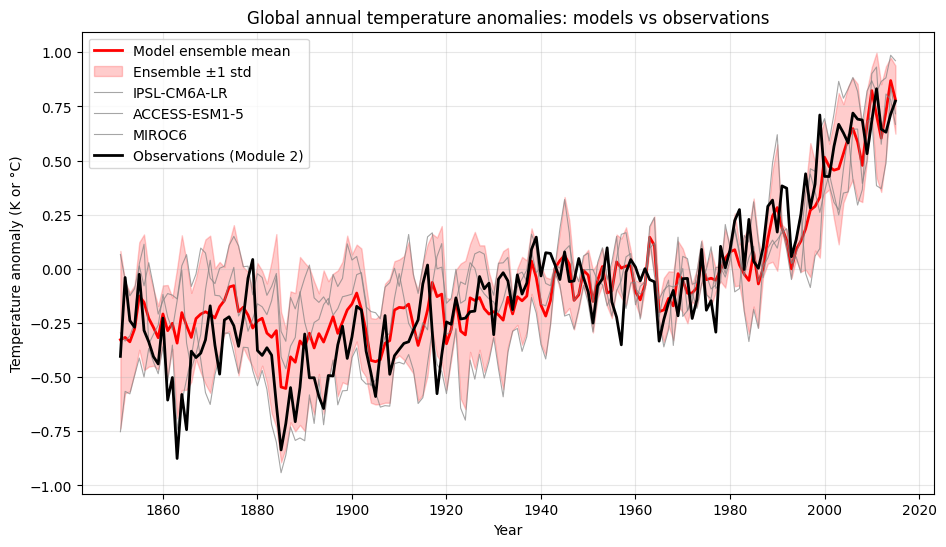

In [105]:
fig = plt.figure(figsize=(11, 6))
ax = plt.gca()

# ensemble mean
ax.plot(df_mod.index, df_mod['ens_mean'], color='red', linewidth=2, label='Model ensemble mean')

# ensemble mean ± standard deviation
ax.fill_between(
    df_mod.index,
    df_mod['ens_mean'] - df_mod['ens_std'],
    df_mod['ens_mean'] + df_mod['ens_std'],
    color='red',
    alpha=0.2,
    label='Ensemble ±1 std'
)

# individual models
ax.plot(df_mod.index, df_mod[model1], color='gray', linewidth=0.8, alpha=0.7, label=model1)
ax.plot(df_mod.index, df_mod[model2], color='gray', linewidth=0.8, alpha=0.7, label=model2)
ax.plot(df_mod.index, df_mod[model3], color='gray', linewidth=0.8, alpha=0.7, label=model3)

# observations
ax.plot(obs.index, obs['obs_gmta'], color='black', linewidth=2, label='Observations (Module 2)')

ax.set_title('Global annual temperature anomalies: models vs observations')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (K or °C)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()